# 01 · Data collection and quality checks

Five daily series, January 2010 to December 2024:

| Ticker | Series |
|---|---|
| `^GSPC` | S&P 500 index |
| `^IXIC` | NASDAQ Composite |
| `GC=F` | Gold futures |
| `CL=F` | WTI crude oil futures |
| `DX-Y.NYB` | US Dollar Index |

The download cell needs internet access and is only needed to refresh `data/raw/market_prices.csv`. Everything after it runs offline from the saved prices.

In [ ]:
# Refresh raw prices (needs internet; not required to run the rest of the project)
import yfinance as yf
tickers = ["^GSPC", "^IXIC", "GC=F", "CL=F", "DX-Y.NYB"]
prices = yf.download(tickers, start="2010-01-01", end="2024-12-31")["Close"]
prices.columns.name = None
prices.to_csv("../data/raw/market_prices.csv")

In [1]:
import sys, json
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import *

pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': 0.3})
COLORS = {'Calm': '#2a9d8f', 'Elevated': '#e9c46a', 'Crisis': '#e63946'}
READ = dict(index_col=0, parse_dates=True, float_precision='round_trip')

In [2]:
prices = pd.read_csv('../data/raw/market_prices.csv', **READ)
print(f"{prices.shape[0]} trading days, {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail(3)

3774 trading days, 2010-01-04 to 2024-12-30


,CL=F,DX-Y.NYB,GC=F,^GSPC,^IXIC
Date,,,,,
2024-12-26,69.6200,108.1300,"2,638.8000","6,037.5898","20,020.3594"
2024-12-27,70.6000,108.0000,"2,617.2000","5,970.8398","19,722.0293"
2024-12-30,70.9900,108.1300,"2,606.1001","5,906.9399","19,486.7891"


## Returns and data quality

`compute_returns` forward-fills prices across market holidays (a closed market earns 0% that day) and then sets to NaN any return computed from a price that is zero or negative.

That rule matters here: WTI crude futures settled at **−$37.63 on 20 April 2020**. A plain percentage change turns that into returns of −306% and −127% on consecutive days. Those are not returns any holder earned, and left in the data they distort averages, correlations and VAR models.

In [3]:
returns = compute_returns(prices)
data_quality_report(prices, returns)

,missing_prices,non_positive_prices,invalid_returns_set_to_nan,min_return,max_return
CL=F,3,1,2,-0.2459,0.3766
DX-Y.NYB,2,0,0,-0.0237,0.0205
GC=F,4,0,0,-0.0935,0.0595
^GSPC,1,0,0,-0.1198,0.0938
^IXIC,1,0,0,-0.1232,0.0935


In [4]:
episode = pd.concat({'price': prices['CL=F'], 'naive pct change': prices['CL=F'].ffill().pct_change(),
                     'cleaned return': returns['CL=F']}, axis=1).loc['2020-04-16':'2020-04-23']
episode

,price,naive pct change,cleaned return
Date,,,
2020-04-16,19.8700,0.0000,0.0000
2020-04-17,18.2700,-0.0805,-0.0805
2020-04-20,-37.6300,-3.0597,NaN
2020-04-21,10.0100,-1.2660,NaN
2020-04-22,13.7800,0.3766,0.3766
2020-04-23,16.5000,0.1974,0.1974


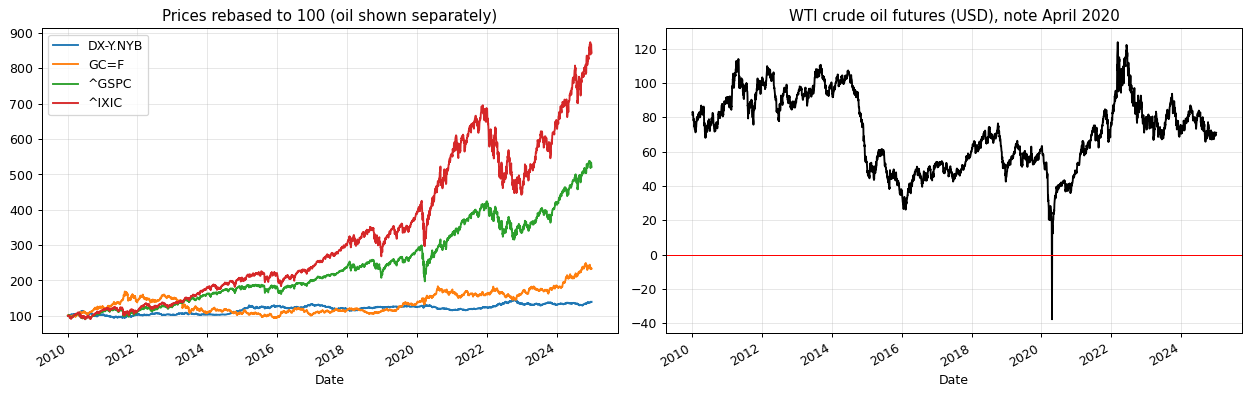

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
(prices / prices.iloc[0] * 100).drop(columns='CL=F').plot(ax=axes[0], title='Prices rebased to 100 (oil shown separately)')
prices['CL=F'].plot(ax=axes[1], color='black', title='WTI crude oil futures (USD), note April 2020')
axes[1].axhline(0, color='red', lw=0.8)
plt.tight_layout()

In [6]:
returns.to_csv('../data/processed/market_returns.csv')
print('Saved data/processed/market_returns.csv', returns.shape)

Saved data/processed/market_returns.csv (3773, 5)
